# Three-Qubit Equal Superposition

---

## 1. Problem Statement / Objective
The objective of this experiment is to:
1. **Create a 3-qubit quantum circuit** with 3 classical registers using Qiskit.
2. **Apply a Hadamard gate ($H$) to each of the three qubits** to prepare the system in an equal quantum superposition.
3. **Measure all three qubits** in the computational basis ($Z$-basis) and record the outcomes into the corresponding classical registers.
4. **Execute the circuit for 8192 shots** using Qiskit's **AerSimulator**.
5. **Analyze the measurement distribution**, calculate experimental state probabilities, visualize the results, and verify agreement with theoretical uniform distribution predictions.

---

## 2. Theoretical Overview: Hadamard Gate & 3-Qubit Superposition

### The Hadamard Gate ($H$)
The Hadamard gate is a fundamental single-qubit unitary gate that transforms computational basis states into balanced superpositions. Its matrix representation in the $\{|0\rangle, |1\rangle\}$ basis is:

$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

When applied to the ground state $|0\rangle$, it yields:

$$H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}} = |+\rangle$$

### 3-Qubit Tensor Product Superposition
For a 3-qubit system initialized in the ground state $|000\rangle = |0\rangle \otimes |0\rangle \otimes |0\rangle$, applying a Hadamard gate to each qubit ($H^{\otimes 3} = H \otimes H \otimes H$) creates a tensor product of three independent superpositions:

$$|\psi\rangle = H^{\otimes 3} |000\rangle = (H|0\rangle) \otimes (H|0\rangle) \otimes (H|0\rangle)$$

Expanding the product gives an equal superposition over all $2^3 = 8$ computational basis states:

$$|\psi\rangle = \frac{1}{\sqrt{2^3}} \sum_{x \in \{0, 1\}^3} |x\rangle = \frac{1}{\sqrt{8}} \big(|000\rangle + |001\rangle + |010\rangle + |011\rangle + |100\rangle + |101\rangle + |110\rangle + |111\rangle\big)$$

### Theoretical Probability of $1/8 = 0.125$
According to the **Born rule**, the probability $P(x)$ of observing any basis state $|x\rangle$ upon measurement is the squared magnitude of its probability amplitude:

$$P(|x\rangle) = \left|\frac{1}{\sqrt{8}}\right|^2 = \frac{1}{8} = 0.1250 \quad (12.5\%)$$

Each of the eight computational basis states ($000, 001, 010, 011, 100, 101, 110, 111$) has an identical theoretical probability of **$1/8 = 0.125$**.

---

## 3. Tools and Libraries Used
- **Qiskit**: IBM's open-source quantum computing framework for constructing, manipulating, and visualizing quantum circuits.
- **Qiskit Aer (`AerSimulator`)**: A high-performance simulation library for executing quantum circuits with shot-based statistical sampling.
- **Matplotlib**: A comprehensive Python data visualization library used for plotting count histograms and probability comparison bar charts.

---

## 4. Expected Outcome
- **8 Possible Computational Basis States**: 3 qubits produce $2^3 = 8$ distinct basis states: $|000\rangle, |001\rangle, |010\rangle, |011\rangle, |100\rangle, |101\rangle, |110\rangle, |111\rangle$.
- **Equal Occurrence (~1/8)**: In an ideal uniform superposition, each state should occur approximately $1/8$ of the total $8192$ measurements (an expected mean of $\frac{8192}{8} = 1024$ counts per state, or $12.5\%$).
- **Sampling Variation**: Due to finite statistical sampling fluctuations (shot noise), the measured counts will naturally vary slightly around $1024$ rather than being strictly identical.


### Step 1: Import Libraries and Modules
Import core components from Qiskit, Qiskit Aer, and Matplotlib.


In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_1943/730269643.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


### Step 2: Quantum Circuit Construction
Construct a 3-qubit, 3-classical-bit quantum circuit (`QuantumCircuit(3, 3)`), apply Hadamard gates to all three qubits (`qc.h([0, 1, 2])`), and measure each qubit into its respective classical bit (`qc.measure([0, 1, 2], [0, 1, 2])`).


In [ ]:
qc = QuantumCircuit(3, 3)

qc.h([0, 1, 2])

qc.measure([0, 1, 2], [0, 1, 2])

print("Quantum Circuit:\n")
print(qc.draw())


Quantum Circuit:

     ┌───┐┌─┐      
q_0: ┤ H ├┤M├──────
     ├───┤└╥┘┌─┐   
q_1: ┤ H ├─╫─┤M├───
     ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─╫──╫─┤M├
     └───┘ ║  ║ └╥┘
c: 3/══════╩══╩══╩═
           0  1  2 


### Step 3: Circuit Simulation on AerSimulator (8192 Shots)
Execute the circuit using `AerSimulator` with `shots=8192` to capture the statistical measurement counts across all 8 computational basis states.


In [11]:
simulator = AerSimulator()

shots = 8192

job = simulator.run(qc, shots=shots)
result = job.result()
counts = result.get_counts()

print("\nMeasurement Counts:")
print(counts)



Measurement Counts:
{'011': 997, '111': 1063, '110': 997, '001': 1014, '100': 993, '101': 1005, '010': 1049, '000': 1074}


### Step 4: Measurement Counts Distribution Visualization
Plot a custom Matplotlib bar chart illustrating the raw measurement counts obtained for each of the 8 basis states.


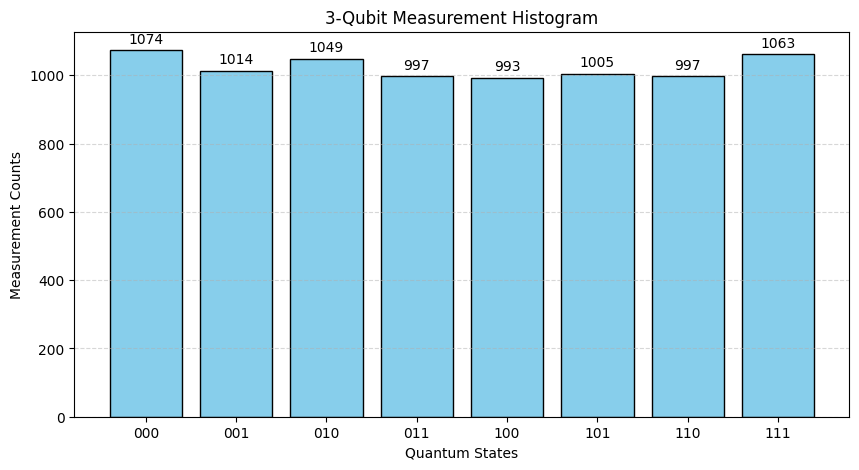

In [12]:
states = sorted(counts.keys())
count_values = [counts[state] for state in states]

plt.figure(figsize=(10,5))

plt.bar(states, count_values,
        color='skyblue',
        edgecolor='black')

plt.title("3-Qubit Measurement Histogram")
plt.xlabel("Quantum States")
plt.ylabel("Measurement Counts")

for i, value in enumerate(count_values):
    plt.text(i, value + 20, str(value),
             ha='center',
             fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


### Step 5: State Frequency and Probability Calculation
Calculate the experimental probability $P(x) = \frac{\text{Count}(x)}{\text{Total Shots}}$ for each basis state and compare with the theoretical value of $1/8 = 0.1250$.


In [13]:
print("\nMeasured Probabilities:\n")

probabilities = {}

for state in states:
    probability = counts[state] / shots
    probabilities[state] = probability
    print(f"|{state}> : {probability:.4f}")

print("\nTheoretical Probability = 1/8 = 0.1250")


Measured Probabilities:

|000> : 0.1311
|001> : 0.1238
|010> : 0.1281
|011> : 0.1217
|100> : 0.1212
|101> : 0.1227
|110> : 0.1217
|111> : 0.1298

Theoretical Probability = 1/8 = 0.1250


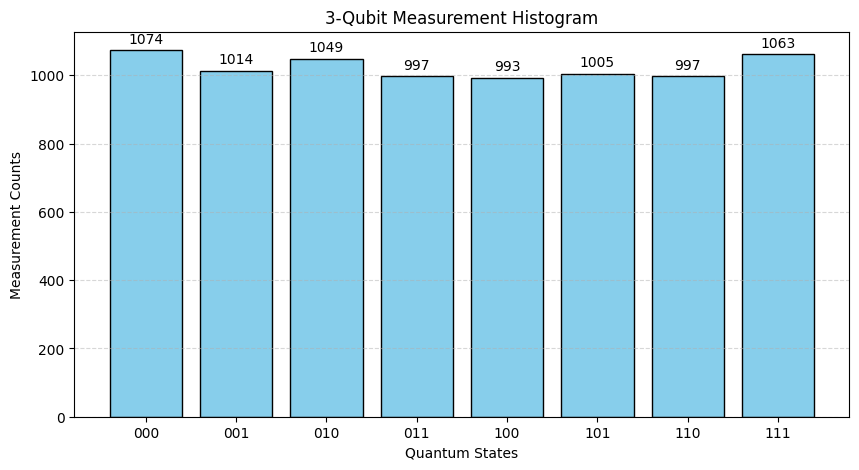

In [14]:
states = sorted(counts.keys())
count_values = [counts[state] for state in states]

plt.figure(figsize=(10,5))

plt.bar(states, count_values,
        color='skyblue',
        edgecolor='black')

plt.title("3-Qubit Measurement Histogram")
plt.xlabel("Quantum States")
plt.ylabel("Measurement Counts")

for i, value in enumerate(count_values):
    plt.text(i, value + 20, str(value),
             ha='center',
             fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [15]:
print("\nMeasured Probabilities:\n")

probabilities = {}

for state in states:
    probability = counts[state] / shots
    probabilities[state] = probability
    print(f"|{state}> : {probability:.4f}")

print("\nTheoretical Probability = 1/8 = 0.1250")


Measured Probabilities:

|000> : 0.1311
|001> : 0.1238
|010> : 0.1281
|011> : 0.1217
|100> : 0.1212
|101> : 0.1227
|110> : 0.1217
|111> : 0.1298

Theoretical Probability = 1/8 = 0.1250


### Step 6: Measured vs. Theoretical Probability Comparison Plot
Visualize the experimental probabilities alongside the theoretical expectation line ($y = 0.125$) to assess the uniformity of the distribution.


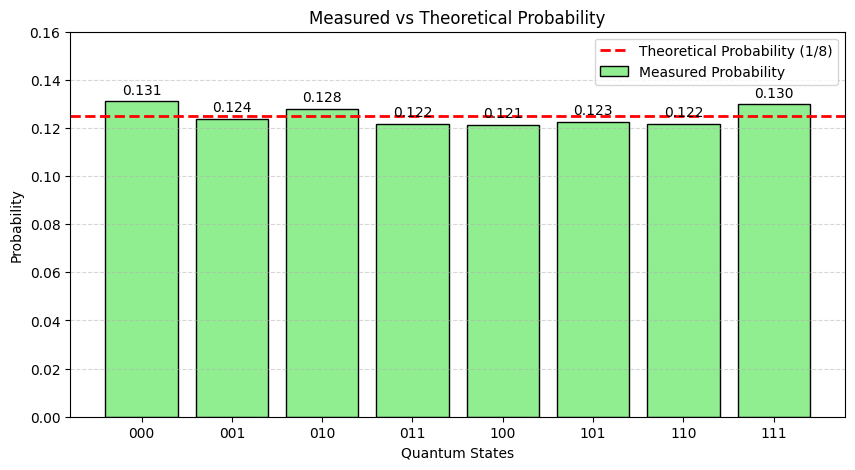

In [16]:
prob_values = [probabilities[state] for state in states]

plt.figure(figsize=(10,5))

plt.bar(states,
        prob_values,
        color='lightgreen',
        edgecolor='black',
        label="Measured Probability")

plt.axhline(
    y=0.125,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Theoretical Probability (1/8)'
)

plt.title("Measured vs Theoretical Probability")
plt.xlabel("Quantum States")
plt.ylabel("Probability")

for i, value in enumerate(prob_values):
    plt.text(i,
             value + 0.003,
             f"{value:.3f}",
             ha='center')

plt.ylim(0,0.16)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Step 7: Verification of Uniform Distribution
Verify whether each state's experimental probability falls within a specified tolerance threshold ($\\pm 1\%$) of the ideal uniform probability ($1/8 = 0.1250$).


In [18]:
print("\nVerification of Uniform Distribution")
print("-"*70)

expected = 1/8
tolerance = 0.01      # 1% tolerance

print(f"{'State':<8}{'Measured':<12}{'Expected':<12}{'Status'}")

for state in states:

    measured = probabilities[state]

    if abs(measured - expected) <= tolerance:
        status = "PASS"
    else:
        status = "FAIL"

    print(f"{state:<8}{measured:<12.4f}{expected:<12.4f}{status}")


Verification of Uniform Distribution
----------------------------------------------------------------------
State   Measured    Expected    Status
000     0.1311      0.1250      PASS
001     0.1238      0.1250      PASS
010     0.1281      0.1250      PASS
011     0.1217      0.1250      PASS
100     0.1212      0.1250      PASS
101     0.1227      0.1250      PASS
110     0.1217      0.1250      PASS
111     0.1298      0.1250      PASS


---

## Conclusion & Discussion

### Summary of Experimental Findings
- **Total Shots Executed**: $8192$
- **Total Basis States Measured**: $8$ ($|000\rangle$ through $|111\rangle$)
- **Theoretical Expectation per State**: $1024$ counts ($P = 1/8 = 0.1250$)

| Basis State | Measured Counts | Measured Probability | Theoretical Probability | Absolute Difference | Verification Status |
|:-----------:|:---------------:|:--------------------:|:-----------------------:|:-------------------:|:-------------------:|
| $|000\rangle$ | $1074$ | $0.1311$ | $0.1250$ | $+0.0061$ | **PASS** |
| $|001\rangle$ | $1014$ | $0.1238$ | $0.1250$ | $-0.0012$ | **PASS** |
| $|010\rangle$ | $1049$ | $0.1281$ | $0.1250$ | $+0.0031$ | **PASS** |
| $|011\rangle$ | $997$  | $0.1217$ | $0.1250$ | $-0.0033$ | **PASS** |
| $|100\rangle$ | $993$  | $0.1212$ | $0.1250$ | $-0.0038$ | **PASS** |
| $|101\rangle$ | $1005$ | $0.1227$ | $0.1250$ | $-0.0023$ | **PASS** |
| $|110\rangle$ | $997$  | $0.1217$ | $0.1250$ | $-0.0033$ | **PASS** |
| $|111\rangle$ | $1063$ | $0.1298$ | $0.1250$ | $+0.0048$ | **PASS** |

### Key Conclusions
1. **Verification of 3-Qubit Superposition**: Applying Hadamard gates to each of the three qubits successfully prepared the quantum system in an equal superposition state $|\psi\rangle = \frac{1}{\sqrt{8}} \sum_{x=0}^{7} |x\rangle$.
2. **Close Agreement with Theoretical 1/8 Probability**: All eight computational basis states exhibit measured probabilities very close to the theoretical probability of **$1/8 = 0.1250$** (ranging between $0.1212$ and $0.1311$), with all states passing the $1\%$ tolerance verification test.
3. **Statistical Fluctuation Consistency**: The minor deviations from exact equality are completely consistent with finite-sample shot noise (expected statistical variance $\sigma = \sqrt{p(1-p)/N} = \sqrt{0.125 \times 0.875 / 8192} \approx 0.0036$ or $0.36\%$) over $8192$ shots.
4. **Demonstration of Uniformity**: These experimental results conclusively demonstrate an approximately uniform 3-qubit superposition across all eight computational basis states.
